In [81]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import torch.nn.functional as F

# load model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14-336")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14-336")

# prepare image and text
image = Image.open("coffeecup.png").convert("RGB")
text = ["A photo of a mug", "A photo of a computer"]

# preprocessing
inputs = processor(text=text, images=image, return_tensors="pt", padding=True)

# extract text inputs
text_inputs = {
    "input_ids": inputs["input_ids"],
    "attention_mask": inputs["attention_mask"]
}

# extract hidden features
with torch.no_grad():
    # text feature
    text_outputs = model.get_text_features(**text_inputs)

    # image feature （per patch）
    vision_outputs = model.vision_model(
        pixel_values=inputs["pixel_values"]
    )
    patch_embeddings = vision_outputs.last_hidden_state  # (1, num_patches+1, hidden_dim)

    # Remove first token（[CLS]）
    patch_features = patch_embeddings[:, 1:, :]  # shape: (1, num_patches, hidden_dim)

    # projection （1024 -> 768）
    projected_patches = model.visual_projection(patch_features)  # shape: (1, num_patches, 768)

    # Normalization
    # patch_features = F.normalize(patch_features, dim=-1)  # Normalize every patch vector
    projected_patches = F.normalize(projected_patches, dim=-1)
    text_features = F.normalize(text_outputs, dim=-1)     # Normalize text feature

    # calculate similarity
    similarity = torch.matmul(projected_patches, text_features.unsqueeze(-1)).squeeze(-1)
    # shape: (1, num_patches)

# result
print("Projected patch features shape:", projected_patches.shape)
print("Text features shape:", text_features.shape)
print("Similarity shape:", similarity.shape)  # similarity per patch
print("Patch-wise similarities:", similarity)

Projected patch features shape: torch.Size([1, 576, 768])
Text features shape: torch.Size([2, 768])
Similarity shape: torch.Size([2, 576])
Patch-wise similarities: tensor([[0.1067, 0.1270, 0.1533,  ..., 0.1249, 0.0974, 0.0836],
        [0.0852, 0.1096, 0.1490,  ..., 0.1595, 0.1386, 0.0771]])


-0.07498099
0.24878798


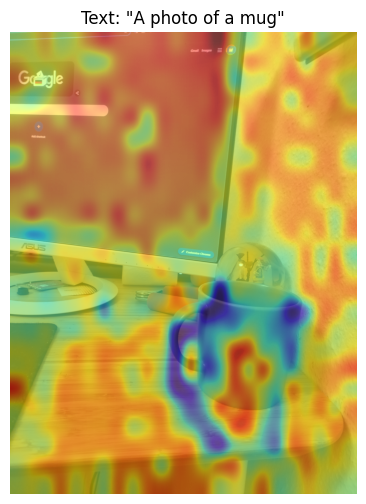

-0.03984531
0.2410438


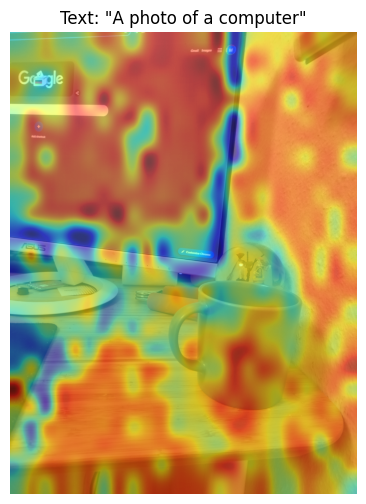

In [82]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.transforms import Resize, Compose, ToTensor

# get image size and the number of the patchs
num_patches = projected_patches.shape[1]
image_size = inputs["pixel_values"].shape[-1]  # 336
patch_size = model.config.vision_config.patch_size  # 14
grid_size = image_size // patch_size  # 336 / 14 = 24 → 24×24 grid

# convert original image to tensor
image_tensor = ToTensor()(image)

# similarity shape: (num_texts, num_patches)
similarity_np = similarity.cpu().numpy()

# create heatmap for each text
for i, text_label in enumerate(text):
    sim = similarity_np[i]  # shape: (num_patches,)
    sim_map = sim.reshape(grid_size, grid_size)  # convert to 24×24
    print(sim_map.min())
    print(sim_map.max())

    # Normalize 0-1
    sim_map = (sim_map - sim_map.min()) / (sim_map.max() - sim_map.min())
    # sim_map = (sim_map + 1) / 2

    # numpy → PIL.Image → resize → numpy
    sim_map_img = Image.fromarray((sim_map * 255).astype(np.uint8)).resize(image.size, resample=Image.BICUBIC)
    sim_map_resized = np.array(sim_map_img) / 255.0

    # overlay as a heat map
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.imshow(sim_map_resized, cmap='jet', alpha=0.5)
    plt.title(f"Text: \"{text_label}\"")
    plt.axis('off')
    plt.show()

In [38]:
import open_clip
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-L-14-336", 
    pretrained="openai", 
    device="cuda", 
    force_image_size=336,)

/home/nanri/anaconda3/envs/llava/lib/python3.10/site-packages/open_clip/factory.py:388: UserWarning: These pretrained weights were trained with QuickGELU activation but the model config does not have that enabled. Consider using a model config with a "-quickgelu" suffix or enable with a flag.
  warnings.warn(


In [56]:
clip_model.encode_image(inputs["pixel_values"].cuda()).shape

torch.Size([1, 768])